# Vision Transformer in Keras (Simple Version)

This notebook shows a simpler version of the Vision Transformer idea in Keras.

The goal is to understand the main steps:
- load a trained CNN,
- take feature maps from the CNN,
- turn them into tokens,
- add position information,
- apply transformer blocks,
- and train the final model.

This version keeps the explanation short and the code easier to read.

## 1. Import libraries

In [1]:
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

c:\Users\Furqan Khan\AppData\Local\miniconda3\envs\agent_env2\lib\site-packages\google\api_core\_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


## 2. Set random seed

In [2]:
seed = 7331
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

## 3. Load the pretrained CNN model

The CNN works as a feature extractor.

In [5]:
from pathlib import Path

CNN_PATH = os.path.join('.', 'ai-capstone-keras-best-model-model_downloaded.keras')
model_path = Path(CNN_PATH)

if not model_path.is_file():
    matches = list(Path.cwd().rglob(model_path.name))
    if matches:
        model_path = matches[0]
    else:
        candidates = [
            p for p in Path.cwd().rglob('*')
            if p.is_file() and p.suffix.lower() in {'.keras', '.h5', '.hdf5'}
        ]

        if len(candidates) == 1:
            model_path = candidates[0]
        elif candidates:
            raise FileNotFoundError(
            "Multiple model files were found. Set CNN_PATH explicitly to the "
            f"correct one:\n{chr(10).join(map(str, candidates))}"
            )
        else:
            raise FileNotFoundError(
            f"Model file '{model_path.name}' was not found under {Path.cwd()}. "
            "Place the model file there or update CNN_PATH to its actual path."
            )

CNN_PATH = str(model_path.resolve())
cnn_model = tf.keras.models.load_model(CNN_PATH, compile=False)
cnn_model.trainable = False
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 415,425 (1.58 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 415,425 (1.58 MB)

## 4. Choose the CNN feature layer

We take the output of a middle layer to turn it into tokens.

In [ ]:
feature_layer_name = 'batch_normalization_5'
features = cnn_model.get_layer(feature_layer_name).output
print(features.shape)

## 5. Add positional embeddings

The transformer does not know the order of tokens by itself, so we add position information.

In [6]:
@tf.keras.utils.register_keras_serializable(package='Custom')
class AddPositionEmbedding(layers.Layer):
    def __init__(self, num_patches, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.pos = self.add_weight(
            name='pos_embedding',
            shape=(1, num_patches, embed_dim),
            initializer='random_normal',
            trainable=True)

    def call(self, tokens):
        return tokens + self.pos

## 6. Define a transformer block

In [7]:
@tf.keras.utils.register_keras_serializable(package='Custom')
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads=8, mlp_dim=2048, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.mha = layers.MultiHeadAttention(num_heads, key_dim=embed_dim)
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.mlp = tf.keras.Sequential([
            layers.Dense(mlp_dim, activation='gelu'),
            layers.Dropout(dropout),
            layers.Dense(embed_dim),
            layers.Dropout(dropout),
        ])

    def call(self, x):
        x = self.norm1(x + self.mha(x, x))
        return self.norm2(x + self.mlp(x))

## 7. Build the hybrid CNN-ViT model

We flatten feature maps into tokens, add positions, pass them through transformer blocks, and classify the result.

In [11]:
feature_layer_name = 'batch_normalization_5'
if 'cnn_model' not in globals():
    raise RuntimeError("Run the CNN loading cell before this cell.")

# Select the last 4D convolutional feature layer whose channels
# are compatible with num_heads=8.
feature_candidates = []

for layer in reversed(cnn_model.layers):
    output_shape = getattr(layer.output, "shape", None)

    if output_shape is not None and len(output_shape) == 4:
        channels = output_shape[-1]

        if channels is not None and int(channels) % 8 == 0:
            feature_candidates.append(layer)

if not feature_candidates:
    raise ValueError(
        "No 4D feature layer with a channel count divisible by 8 was found."
    )

feature_layer_name = feature_candidates[0].name
features = feature_candidates[0].output

print(f"Using feature layer: {feature_layer_name}")
print(f"Feature shape: {features.shape}")

H, W, C = features.shape[1], features.shape[2], features.shape[3]

x = layers.Reshape((H * W, C))(features)
x = AddPositionEmbedding(H * W, C)(x)

for _ in range(4):
    x = TransformerBlock(C, num_heads=8, mlp_dim=2048)(x)

x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(2, activation='softmax')(x)

# Rebuild the loaded Sequential model as a Functional graph.
# This avoids cnn_model.input being undefined after loading.
cnn_input_shape = tuple(cnn_model.input_shape[1:])
cnn_input = layers.Input(shape=cnn_input_shape, name="image_input")

z = cnn_input
feature_map = None

for cnn_layer in cnn_model.layers:
    if isinstance(cnn_layer, layers.InputLayer):
        continue

    z = cnn_layer(z)

    if cnn_layer.name == feature_layer_name:
        feature_map = z

if feature_map is None:
    raise ValueError(f"Feature layer '{feature_layer_name}' was not found.")

H = int(feature_map.shape[1])
W = int(feature_map.shape[2])
C = int(feature_map.shape[3])

x = layers.Reshape((H * W, C))(feature_map)
x = AddPositionEmbedding(H * W, C)(x)

for _ in range(4):
    x = TransformerBlock(C, num_heads=8, mlp_dim=2048)(x)

x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(2, activation="softmax")(x)

hybrid_model = Model(cnn_input, outputs, name="CNN_ViT_Hybrid")
hybrid_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

hybrid_model.summary()

Using feature layer: max_pooling2d_3
Feature shape: (None, 2, 2, 128)


Model: "CNN_ViT_Hybrid"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 4, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_position_embedding_2        │ (None, 4, 128)         │           512 │
│ (AddPositionEmbedding)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_8             │ (None, 4, 128)         │     1,054,464 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_9             │ (None, 4, 128)         │     1,054,464 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_10            │ (None, 4, 128)         │     1,054,464 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_11            │ (None, 4, 128)         │     1,054,464 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,459,458 (17.01 MB)

 Trainable params: 4,218,626 (16.09 MB)

 Non-trainable params: 240,832 (940.75 KB)

## 8. Prepare image data

Use augmentation and image generators for training and validation.

In [13]:
DATASET_PATH = os.path.join('.', 'images_dataSAT')

img_w, img_h = 64, 64
batch_size = 4

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=30,
    horizontal_flip=True,
)

dataset_path = Path(DATASET_PATH)

if not dataset_path.is_dir():
    matches = [
        p for p in Path.cwd().rglob(dataset_path.name)
        if p.is_dir()
    ]

    if len(matches) == 1:
        dataset_path = matches[0]
    elif not matches:
        raise FileNotFoundError(
            f"Dataset folder '{dataset_path}' was not found. "
            f"Place it under {Path.cwd()} or update DATASET_PATH."
        )
    else:
        raise FileNotFoundError(
            "Multiple dataset folders found:\n"
            + "\n".join(map(str, matches))
        )

DATASET_PATH = str(dataset_path.resolve())

train_gen = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(img_w, img_h),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_gen = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(img_w, img_h),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

print(train_gen.class_indices)

Found 4800 images belonging to 2 classes.
Found 1200 images belonging to 2 classes.
{'class_0_non_agri': 0, 'class_1_agri': 1}


## 9. Train the model

In [14]:
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    'vision_transformer_simple.keras',
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    verbose=1
)

history = hybrid_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=3,
    steps_per_epoch=128,
    callbacks=[checkpoint_cb],
    verbose=1
)

Epoch 1/3
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.9410 - loss: 0.1872
Epoch 1: val_loss improved from None to 0.07285, saving model to vision_transformer_simple.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 46s 182ms/step - accuracy: 0.9688 - loss: 0.1164 - val_accuracy: 0.9733 - val_loss: 0.0729
Epoch 2/3
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9642 - loss: 0.0885
Epoch 2: val_loss improved from 0.07285 to 0.06659, saving model to vision_transformer_simple.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 22s 169ms/step - accuracy: 0.9766 - loss: 0.0852 - val_accuracy: 0.9725 - val_loss: 0.0666
Epoch 3/3
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9804 - loss: 0.0477
Epoch 3: val_loss improved from 0.06659 to 0.05421, saving model to vision_transformer_simple.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 18s 145ms/step - accuracy: 0.9844 - loss: 0.0563 - val_accuracy: 0.9817 - val_loss: 0.0542


## 10. Check the training curve

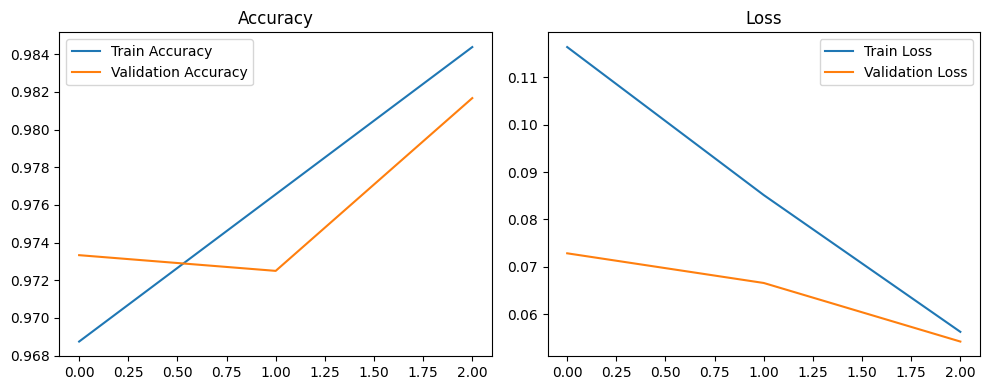

In [15]:
plt = tf.keras.utils.plot_model

# accuracy plot
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].plot(history.history['accuracy'], label='Train Accuracy')
axs[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axs[0].set_title('Accuracy')
axs[0].legend()

axs[1].plot(history.history['loss'], label='Train Loss')
axs[1].plot(history.history['val_loss'], label='Validation Loss')
axs[1].set_title('Loss')
axs[1].legend()

plt.tight_layout()
plt.show()

## Summary

This notebook shows the main idea behind a CNN-ViT hybrid model:
- CNN extracts important image features,
- transformer learns relationships between them,
- and the final layer predicts the class.

The method is useful because it combines local pattern learning from CNNs and global context learning from transformers.